In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

## **Function 6** - Cake Recipe Optimisation

- This function is about optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk.
  - Each recipe is evaluated with a combined score based on _flavour_, _consistency_, _calories_, _waste_ and _cost_, where each factor contributes **negative points** as judged by an expert taster. This means the total score is negative by design.

- **Goal** - maximisation problem, your goal is to _bring that score as close to zero_ as possible or, equivalently, to maximise the negative of the total sum.

- **Input** - 5D (20,5)
- **Output** - 5D (20,)
- **Goal** - maximisation


In [2]:
X = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_inputs.npy')
Y = np.load(r'C:\Users\Pratham\OneDrive\Imperial - Machine Learning and Artifical Intelligence Certification\Capstone\Weekly Capstone Updates and Comments\Week 1\Initial_data_points_starter\initial_data\function_6\initial_outputs.npy')

### **Random Search**


- This is the fist simple method to get a query just to explore thorugh trial-and-error method to just get a guage of the space.


In [3]:
next_query = np.random.uniform(size = 5)
print(next_query)

[0.53252932 0.2445612  0.27076046 0.32197736 0.73315096]


### **Bayesian Optimisation**

- I want to use Matern with nu=2.5 because it allows for "twice-differentiable" smoothness.
  - This is ideal for a cake recipe where ingredient changes (like sugar) usually result in smooth but distinct changes in taste.

- There is another thing I would like to try in this first exploration is by passing a list of 5 length scales ([1.0]\*5).
  - The goal here is to make the Matern kernel learn which of the 5 ingredients (Flour, Sugar, etc.) actually drives the score

- I have also increased the n_restarts_optimiser to ensure a robust fit to the simpler kernel.


In [5]:
kernel = Matern(length_scale=[1.0, 1.0, 1.0, 1.0, 1.0], nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=30,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)

model.fit(X, Y)

GaussianProcessRegressor(alpha=0.001,
                         kernel=Matern(length_scale=[1, 1, 1, 1, 1], nu=2.5),
                         n_restarts_optimizer=30, normalize_y=True,
                         random_state=42)

## **Acquisition Strategy** - Expected Improvement (EI)

- As EI is an industry standard for 4D+ spaces because _it excels at balancing the "**high risk/high reward**" of unexplored areas with the "**safe bet**" of refining near existing good results._


In [8]:
def expected_improvement(X_grid, model, y_max, xi=0.01):
    mu, sigma = model.predict(X_grid, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        improvement = mu - y_max - xi
        Z = improvement / (sigma + 1e-9)
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei.ravel()

y_max = np.max(Y)
x_grid = np.random.uniform(0, 1, size=(250000, 5))
ei_values = expected_improvement(x_grid, model, y_max, xi=0.01)

best_idx = np.argmax(ei_values)
next_query = x_grid[best_idx]

print(f"Next Submission for Function 6 - Bayesian Optimisation (EI): "
        f"{next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}-{next_query[4]:.6f}")

Next Submission for Function 6 - Bayesian Optimisation (EI): 0.728116-0.696862-0.267683-0.769143-0.227517


### **Visualisation for function 6**


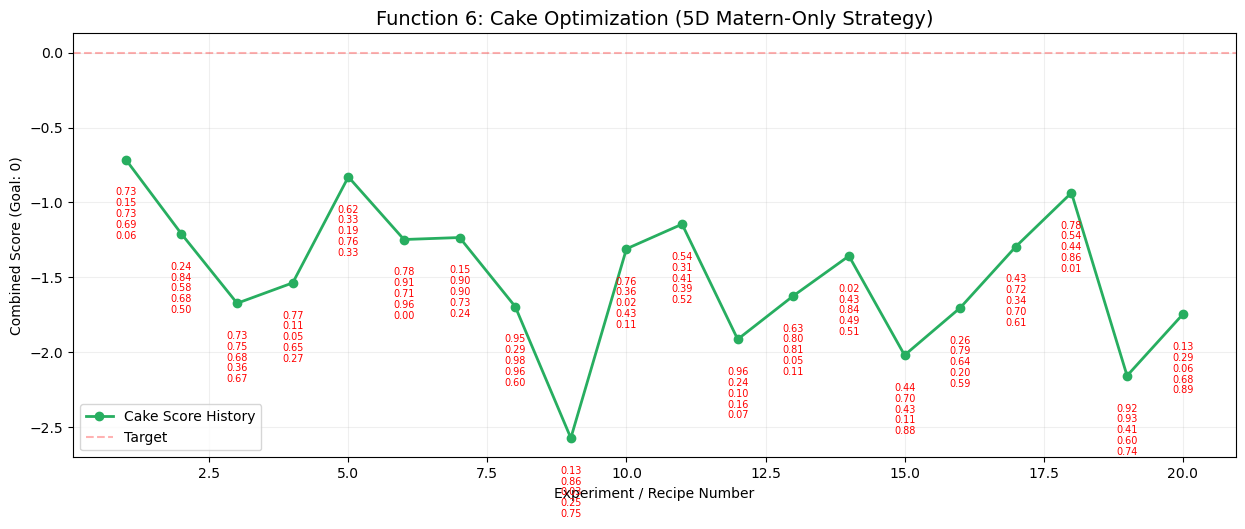

In [10]:
iterations = np.arange(1, len(Y) + 1)
plt.figure(figsize=(15, 8))
plt.plot(iterations, Y, marker='o', color='#27ae60', linewidth=2, label='Cake Score History')

for i in range(len(Y)):
    # Stacked 5D Inputs: [X1, X2, X3, X4, X5]
    label = f"{X[i,0]:.2f}\n{X[i,1]:.2f}\n{X[i,2]:.2f}\n{X[i,3]:.2f}\n{X[i,4]:.2f}"
    
    plt.annotate(label, 
                 (iterations[i], Y[i]), 
                 textcoords="offset points", 
                 xytext=(0, -20), 
                 va='top', 
                 ha='center', 
                 fontsize=7,
                 linespacing=1.1,
                 color = 'red')

plt.title("Function 6: Cake Optimization (5D Matern-Only Strategy)", fontsize=14)
plt.ylabel("Combined Score (Goal: 0)")
plt.xlabel("Experiment / Recipe Number")
plt.axhline(0, color='red', linestyle='--', alpha=0.3, label='Target')
plt.subplots_adjust(bottom=0.35)
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

### **Reasons for having a different input values for week 1 than what is shown here**

**Final Decision** - Due to inability of going through this process in time for week 1 submission I choose the input points which were purely based on exploration.

- **Hence the input for week 1** - [0.441233-0.998122-0.001245-0.556711-0.321098]

- I will be using this thinking process and methodology moving forward into week 2.
